In [1]:
import jax
from jax import lax
from jax import numpy as jnp
from jax.tree_util import Partial

import polars as pl
import re
from matplotlib import pyplot as plt

from gm_scenario import *
from ASK14 import ASK14

# theft https://github.com/usgs/nshmp-haz/blob/main/src/gov/usgs/earthquake/nshmp/gmm/ChiouYoungs_2014.java

In [2]:
gmc = pl.read_csv('CY14_coeffs.csv')
gmc[-2, 'T'] = -1.
gmc[-1, 'T'] = -2.
gmc_col = gmc.columns
gmc = gmc.cast(pl.Float64).to_jax().T
T = gmc[0]
empty = jnp.zeros_like(T)

c_RB = gmc[4]
c_n, c_M, c_HM = gmc[jnp.array([12, 13, 16])]
c = jnp.empty((12, 5, T.shape[0]))
# c1, c1a - d
c = c.at[1].set(gmc[7:12])
# c2
c = c.at[2, 0].set(gmc[1])
# c3
c = c.at[3, 0].set(gmc[14])
# c4
c = c.at[4, 0:2].set(gmc[2:4])
# c5 - c7
c = c.at[5:8, 0].set(gmc[jnp.array([15, 17, 18])])
# c8
c = c.at[8, 0:3].set(gmc[jnp.array([5, 6, 20])])
# c9, c9a, c9b
c = c.at[9, 0:3].set(gmc[21:24])
# c11, c11b
c = c.at[11, jnp.array([0, 2])].set(gmc[24:26])
# c_gamma
c_gamma = jnp.insert(gmc[26:29], 0, empty, axis = 0)
phi = jnp.insert(gmc[29:35], 0, empty, axis = 0)
tau = jnp.insert(gmc[35:37], 0, empty, axis = 0)
sigma = jnp.insert(gmc[37:40], 0, empty, axis = 0)
sigma2_JP, gamma_JP_IT, gamma_WN = gmc[40:43]
phi1_JP, phi5_JP, phi6_JP = gmc[43:]

z_tor_const_RV = jnp.array([2.704, 1.226, 5.849])
z_tor_const_NM = jnp.array([2.673, 1.136, 4.97])

In [3]:
# Taking all of this from eqn. 11

# 0 is SS, 1 is RV, 2 is NM
def f_SOF_flag(dip):
    RV_flag = (30 <= dip <= 150)
    NM_flag = (-120 <= dip <= -60) * 2
    SOF_flag = jnp.max(jnp.array([RV_flag, NM_flag]))
    return SOF_flag

# Base model
def f_base(Mw):
    return c[1, 0] + \
           c[2, 0] * (Mw - 6.) + \
           (c[2, 0] - c[3, 0]) / c_n * \
                jnp.log(1 + jnp.exp(c_n * (c_M - Mw)))

# Near-field scaling
def f_near_field(Mw, R_rup):
    cosh_part = jnp.cosh(c[6, 0] * jnp.clip(Mw - c_HM, min = 0))
    return c[4, 0] * jnp.log(R_rup + c[5, 0] + cosh_part)

# Far-field scaling
def f_far_field(Mw, R_rup):
    gamma = c_gamma[1] + \
            c_gamma[2] / jnp.cosh(jnp.clip(Mw - c_gamma[3], min = 0))
    return (c[4, 1] - c[4, 0]) * \
            jnp.log((R_rup ** 2 + c_RB ** 2) ** (1 / 2)) + \
            gamma * R_rup

def f_SOF(Mw, SOF_flag):
    cosh_mag = jnp.cosh(2 * jnp.clip(Mw - 4.5, min = 0))
    
    c_add_SOF = lax.select_n(SOF_flag, empty, c[1, 1], c[1, 2])
    c_div_SOF = lax.select_n(SOF_flag, empty, c[1, 2], c[1, 3])
    return c_add_SOF + c_div_SOF / cosh_mag

def f_z_tor(Mw, SOF_flag, z_tor):
    cosh_mag = jnp.cosh(2 * jnp.clip(Mw - 4.5, min = 0))

    z_tor_const = lax.select(SOF_flag == 1, z_tor_const_RV, z_tor_const_NM)
    Mw_capped = jnp.clip(Mw - z_tor_const[-1], min = 0)
    # Magnitude-estimated z-tor
    E_z_tor = jnp.clip(z_tor_const[0] - z_tor_const[1] * Mw_capped, min = 0) ** 2
    d_z_tor = z_tor - E_z_tor
    return (c[7, 0] + c[7, 2] / cosh_mag) * d_z_tor

def f_dip(Mw, dip):
    cosh_mag = jnp.cosh(2 * jnp.clip(Mw - 4.5, min = 0))
    return (c[11, 0] + c[11, 2] / cosh_mag) * jnp.cos(dip) ** 2

# Use hanging wall flag
def f_HW(dip, 
         R_rup, R_jb, R_x, 
         z_tor):
    front = c[9, 0] * jnp.cos(dip)
    middle = c[9, 1] + (1 - c[9, 1]) * jnp.tanh(R_x / c[9, 2])
    end = 1 - (R_jb ** 2 + z_tor ** 2) ** (1 / 2) / (R_rup + 1)
    return front * middle * end

# Not implemented!
def f_directivity():
    return empty


def f_lnSA(Mw, width, dip, 
           R_rup, R_jb, R_x,
           z_tor):
    SOF_flag = f_SOF_flag(dip)
    return f_base(Mw) + \
            f_near_field(Mw, R_rup) + \
            f_far_field(Mw, R_rup) + \
            f_SOF(Mw, SOF_flag) + \
            f_z_tor(Mw, SOF_flag, z_tor) + \
            f_dip(Mw, dip) + \
            f_directivity() + \
            f_HW(dip, R_rup, R_jb, R_x, z_tor)

def dummy(scn:gm_scenario):
    return T, f_lnSA(scn.Mw, scn.width, scn.dip, scn.R_rup, scn.R_jb, scn.R_x, scn.z_tor), empty

['T', 'e0', 'e1', 'e2', 'e3', 'e4', 'e5', 'e6', 'Mh', 'c1', 'c2', 'c3', 'Mref', 'Rref', 'h', 'Dc3CaTw', 'Dc3CnTr', 'Dc3ItJp', 'c', 'Vc', 'Vref', 'f1', 'f3', 'f4', 'f5', 'f6', 'f7', 'R1', 'R2', 'dPhiR', 'dPhiV', 'v1', 'v2', 'phi1', 'phi2', 'tau1', 'tau2']


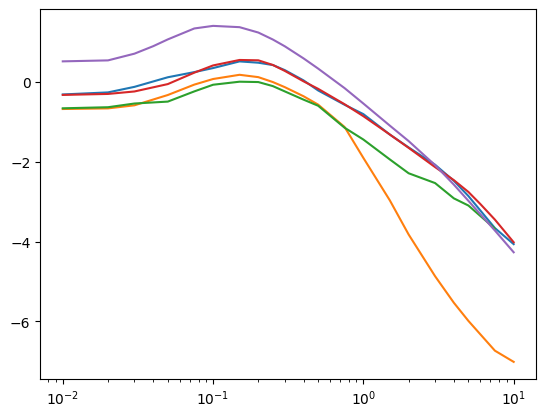

In [4]:
from CB14 import CB14
from BSSA14 import BSSA14 
from Idriss14 import Idriss14
from ASK14 import ASK14

scn = gm_default()
for model in [CB14, BSSA14, Idriss14, ASK14, dummy]:
    t,sa,_ = model(scn)
    plt.plot(t[:-2], sa[:-2])
plt.xscale('log')
plt.show()



"""
true_ask14:
- Mandatory:
    - dip (float)
    - dist_jb (float)
    - dist_rup (float)
    - dist_x (float)
    - mag (float)
    - mechanism (str, "SS", "NS", "RS")
    - v_s30
- Optional:
    - depth_1_0 (float)
    - depth_2_5 (float)
    - depth_tor (float)
    - depth_bor (float)
    - dist_y0 (float)
    - on_hanging_wall (bool, None = false)
    - region (str, 'global', 'cali', 'china', 'italy', 'japan', 'taiwan')
    - vs_source (str, 'measured', 'inferred')
    - width (float, none = model average)
"""